# MVP Análise de Dados e Boas Práticas

**Nome:** Isadora Silva de Sousa

**Matrícula:** 4052025002210

**Dataset:** https://www.kaggle.com/datasets/danielgrijalvas/movies

#Descrição do Problema

A indústria cinematográfica movimenta bilhões de dólares anualmente, envolvendo decisões estratégicas relacionadas a orçamento, elenco, gênero e distribuição. No entanto, nem sempre é claro quais fatores contribuem diretamente para o sucesso de um filme, seja em termos de faturamento ou avaliação do público.

Diante disso, este projeto tem como objetivo analisar um conjunto de dados contendo informações sobre filmes lançados entre 1980 e 2020, incluindo variáveis como orçamento (*budget*), faturamento (*gross*), avaliação (*score*), número de votos (*votes*), gênero (genre) e outros atributos relevantes.

O problema central consiste em identificar quais características estão mais associadas ao sucesso de um filme, permitindo extrair insights que possam apoiar decisões na indústria do entretenimento.

##Hipóteses do Problema

As hipóteses traçadas foram as seguintes:

1.   Filmes com maior orçamento geram maior faturamento?
2.   Existem gêneros cinematográficos mais lucrativos do que outros?
3.   Filmes produzidos por determinadas empresas apresentam melhor desempenho financeiro?



##Tipo de Problema

Este projeto caracteriza-se como uma análise exploratória de dados (Exploratory Data Analysis – EDA), com o objetivo de identificar padrões, relações e tendências em um conjunto de dados de filmes.

O foco está na investigação de fatores que possam influenciar o desempenho financeiro dos filmes, especialmente o faturamento (*gross*).

##Seleção de Dados

O conjunto de dados utilizado contém informações sobre filmes lançados entre 1980 e 2020, incluindo variáveis relacionadas a orçamento, faturamento, avaliações e características de produção.

O dataset foi obtido a partir de uma base pública disponível na plataforma Kaggle, sendo previamente estruturado, porém ainda exigindo etapas de limpeza e tratamento de dados, como o tratamento de valores ausentes e ajuste de tipos de variáveis.

##Atributos do Dataset

O dataset possui aproximadamente 7.668 registros e 15 variáveis, descritas a seguir:

*   ***name***  (nome do filme)
*   ***rating*** (classificação indicativa)
*   ***genre*** (gênero do filme)
*   ***year*** (ano de lançamento)
*   ***released*** (data de lançamento)
*   ***score*** (avaliação média do filme)
*   ***votes*** (número de votos/avaliações)
*   ***director*** (diretor do filme)
*   ***writer*** (roteirista)
*   ***star*** (ator principal)
*   ***country*** (país de origem)
*   ***budget*** (orçamento de produção)
*   ***gross*** (faturamento bruto)
*   ***company*** (produtora)
*   ***runtime*** (duração do filme em minutos)


# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Movie Industry.

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler #normalização
from sklearn.preprocessing import StandardScaler #padronização
from sklearn.preprocessing import OrdinalEncoder #ordinal encoding
from sklearn.preprocessing import OneHotEncoder #one-hot encoding e dummy encoding

###Download do dataset e conversão para dataframe

In [149]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "movies.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "danielgrijalvas/movies",
  file_path)

/tmp/ipykernel_7819/678969983.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'movies' dataset.


In [150]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


# Análise de Dados

Nesta etapa de Análise Exploratória de Dados (Exploratory Data Analysis – EDA), busca-se compreender a distribuição, as relações e as características das variáveis presentes no dataset de filmes. Essa análise é fundamental para orientar as etapas posteriores de pré-processamento e extração de insights.

## Total e Tipo das Instâncias

O dataset utilizado possui aproximadamente 7.668 instâncias (observações), onde cada instância representa um filme.

As variáveis do conjunto de dados são compostas por diferentes tipos:

**Variáveis numéricas:** incluem atributos como ***year***, ***score***, ***votes***, ***budget***, ***gross*** e ***runtime***, que representam informações quantitativas relacionadas aos filmes.

**Variáveis categóricas:** incluem atributos como ***name***, ***rating***, ***genre***, ***director***, ***writer***, ***star***, ***country*** e ***company***, que representam características descritivas dos filmes.

**Variáveis de data:** a coluna ***released***, que representa a data de lançamento, inicialmente está no formato de texto e pode ser convertida para o tipo datetime para facilitar análises temporais.

A diversidade de tipos de variáveis permite a realização de análises tanto quantitativas quanto qualitativas, possibilitando uma compreensão mais abrangente dos fatores que influenciam o desempenho dos filmes.

In [151]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 7668

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   released  7666 non-null   object 
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   object 
 8   writer    7665 non-null   object 
 9   star      7667 non-null   object 
 10  country   7665 non-null   object 
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   object 
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB
None


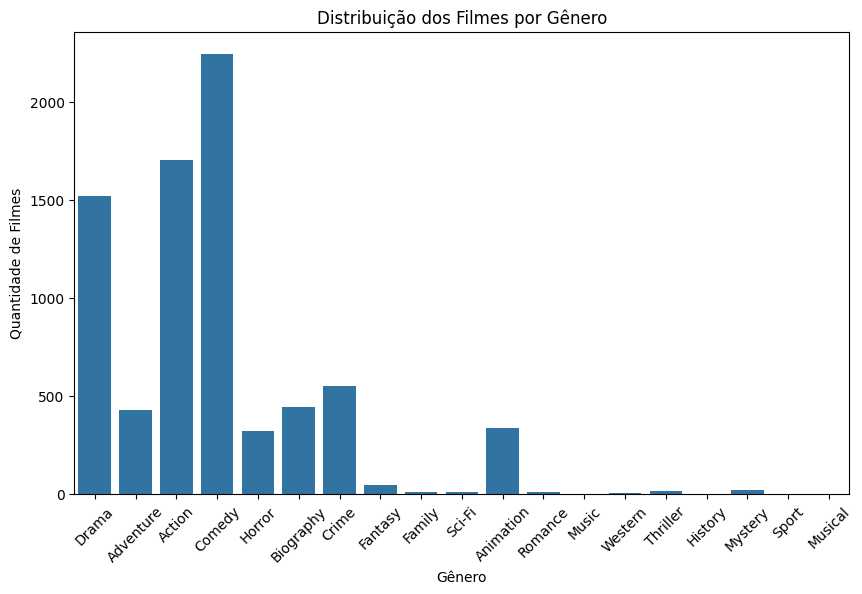

In [152]:
plt.figure(figsize=(10, 6))

sns.countplot(x='genre', data=df)

plt.title('Distribuição dos Filmes por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Filmes')

plt.xticks(rotation=45)  # para não sobrepor os nomes
plt.show()

Nota-se que determinados gêneros concentram um maior número de filmes, enquanto outros possuem uma significativa menor representatividade. Esse desbalanceamento deve ser considerado nas análises, pois pode impactar a interpretação dos resultados relacionados ao desempenho financeiro por gênero, por exemplo.

<Axes: xlabel='count', ylabel='country'>

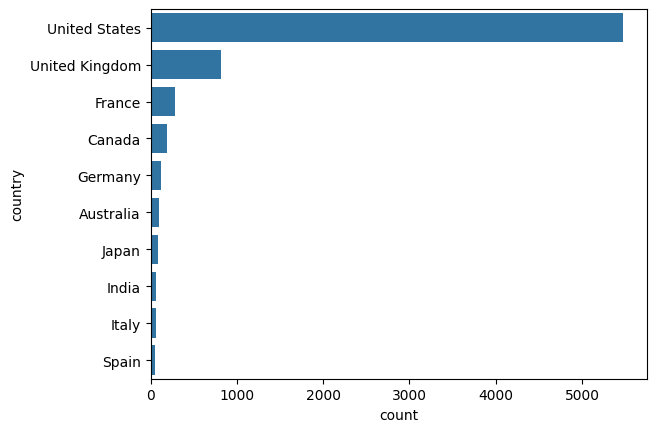

In [153]:
sns.countplot(y='country', data=df, order=df['country'].value_counts().iloc[:10].index)

A análise da distribuição por país revela que a maioria dos filmes é originária dos Estados Unidos, evidenciando também um desbalanceamento geográfico no conjunto de dados. Esse resultado reflete a forte presença da indústria cinematográfica norte-americana no mercado global.

Esse desbalanceamento pode influenciar os resultados das análises, especialmente aquelas relacionadas ao desempenho financeiro, uma vez que o mercado cinematográfico dos Estados Unidos possui características específicas, como maior investimento e maior alcance de público.

Como possível extensão, seria interessante comparar o desempenho financeiro entre filmes produzidos nos Estados Unidos e em outros países, a fim de avaliar diferenças estruturais no mercado cinematográfico.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [154]:
df.shape

(7668, 15)

In [155]:
df.describe()

,year,score,votes,budget,gross,runtime
count,7668.000000,7665.000000,7.665000e+03,5.497000e+03,7.479000e+03,7664.000000
mean,2000.405451,6.390411,8.810850e+04,3.558988e+07,7.850054e+07,107.261613
std,11.153508,0.968842,1.633238e+05,4.145730e+07,1.657251e+08,18.581247
min,1980.000000,1.900000,7.000000e+00,3.000000e+03,3.090000e+02,55.000000
25%,1991.000000,5.800000,9.100000e+03,1.000000e+07,4.532056e+06,95.000000
50%,2000.000000,6.500000,3.300000e+04,2.050000e+07,2.020576e+07,104.000000
75%,2010.000000,7.100000,9.300000e+04,4.500000e+07,7.601669e+07,116.000000
max,2020.000000,9.300000,2.400000e+06,3.560000e+08,2.847246e+09,366.000000


##Média, Mediana e Desvio Padrão

In [156]:
# média dos atributos numéricos do dataset
df.describe().loc['mean']

,mean
year,2.000405e+03
score,6.390411e+00
votes,8.810850e+04
budget,3.558988e+07
gross,7.850054e+07
runtime,1.072616e+02


Vamos usar ***gross*** (faturamento) para uma primeira análise das hipóteses.

In [157]:
print("Média:", df['gross'].mean())
print("Mediana:", df['gross'].median())
print("Desvio padrão:", df['gross'].std())

Média: 78500541.01778312
Mediana: 20205757.0
Desvio padrão: 165725124.31875733


A análise das medidas estatísticas do faturamento (gross) revela uma distribuição altamente assimétrica. A média (77 milhões) é significativamente superior à mediana (20 milhões), indicando que poucos filmes com faturamento extremamente elevado influenciam o valor médio.

Além disso, o elevado desvio padrão (163 milhões) demonstra grande variabilidade nos dados, evidenciando que o faturamento dos filmes apresenta ampla dispersão. Dessa forma, conclui-se que a mediana representa de forma mais fiel o comportamento típico do dataset do que a média.

Com isso, podemos dizer que o sucesso financeiro no cinema é altamente concentrado em poucos filmes.

##Histograma

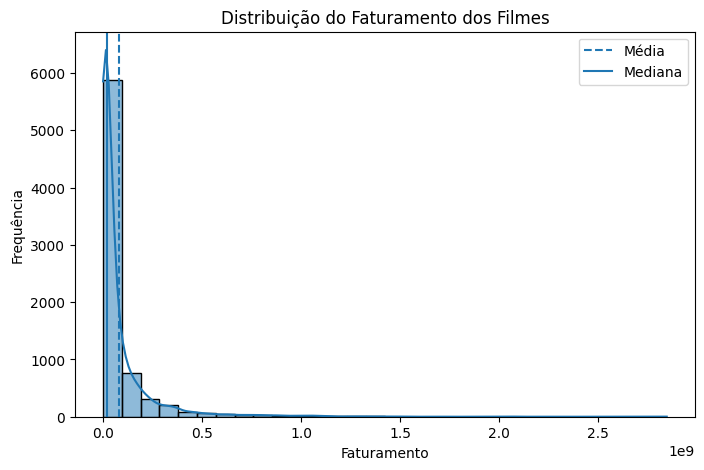

In [158]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(df['gross'], bins=30, kde=True)

# média
plt.axvline(df['gross'].mean(), linestyle='--', label='Média')

# mediana
plt.axvline(df['gross'].median(), linestyle='-', label='Mediana')

plt.title('Distribuição do Faturamento dos Filmes')
plt.xlabel('Faturamento')
plt.ylabel('Frequência')

plt.legend()
plt.show()

**INTERPRETAÇÃO DO GRÁFICO**

- O histograma do faturamento dos filmes, juntamente com a linha indicativa da média, permite observar a distribuição dos valores. Nota-se que a média é influenciada por valores extremos, indicando possível assimetria na distribuição dos dados;

- A análise da distribuição do faturamento (***gross***) dos filmes evidencia uma assimetria nos dados, com concentração de valores em faixas mais baixas e presença de valores extremos elevados;

- A média apresenta valor superior à mediana, indicando que a distribuição é assimétrica à direita, sendo influenciada por filmes com faturamento muito alto;

- O desvio padrão elevado reforça a existência de grande variabilidade nos dados, evidenciando que o faturamento dos filmes varia significativamente;

- Dessa forma, observa-se que a mediana pode ser uma medida mais representativa do comportamento central dos dados do que a média, devido à presença de outliers.

##Boxplot

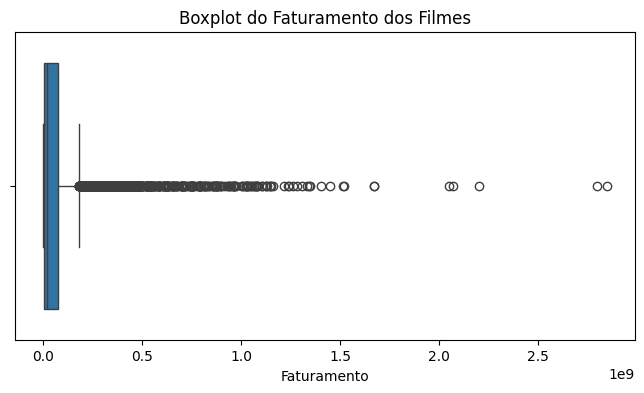

In [159]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

sns.boxplot(x=df['gross'])

plt.title('Boxplot do Faturamento dos Filmes')
plt.xlabel('Faturamento')

plt.show()

**INTERPRETAÇÃO DO GRÁFICO**

- O box representa os 50% centrais dos dados (entre 25% e 75%). No gráfico, essa caixa está bem comprimida perto do zero;

- A mediana (linha dentro da caixa) também está bem à esquerda (valores baixos);

- Os whiskers (intervalo dos dados sem outliers) vão apenas até um certo ponto;

- O gráfico possui muitos outliers;

- Distribuição altamente assimétrica à direita.

**CONCLUSÃO**

O boxplot do faturamento dos filmes revela uma forte assimetria na distribuição dos dados, com a maioria dos valores concentrados em faixas mais baixas e a presença de numerosos outliers.



**Principais Observações**


1- Faturamento Predominante

*   A maior parte dos filmes apresenta faturamento relativamente baixo;
*   Poucos filmes alcançam valores extremamente elevados.

2- Impacto da Média e Mediana
*   Os valores extremos contribuem para o aumento da média;
*   Isso explica a diferença significativa entre média e mediana.

3- Distribuição de Receitas
*   O faturamento dos filmes não segue uma distribuição uniforme;
*   O sucesso financeiro na indústria cinematográfica é concentrado em poucos filmes, caracterizando uma distribuição desigual de receitas.

4- Relação com a Indústria
*   A presença de valores extremos pode estar relacionada à estrutura da indústria, marcada por poucos grandes sucessos comerciais;
*   O crescimento do mercado ao longo das últimas décadas também é um fator relevante, como veremos a seguir.

##Lineplot

<Axes: xlabel='year', ylabel='gross'>

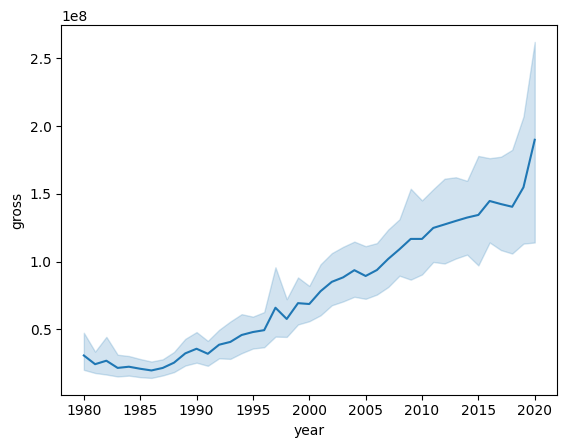

In [160]:
sns.lineplot(x='year', y='gross', data=df)

Considerando que o dataset abrange o período de 1980 a 2020, é possível que filmes mais recentes apresentem maiores valores de faturamento devido ao aumento dos investimentos, da inflação e da expansão do público global, contribuindo para a assimetria observada nos dados. Dessa forma, a análise do faturamento deve considerar o fator temporal como uma variável relevante para a interpretação dos resultados.

##Tratamento de Valores Nulos

In [161]:
# Verificar a presença de valores nulos no dataset original
df.isnull().sum()

,0
name,0
rating,77
genre,0
year,0
released,2
score,3
votes,3
director,0
writer,3
star,1


Observa-se que:

***budget:*** muitos valores faltantes

***gross:*** alguns faltantes

***outras colunas:*** poucos ou quase nenhum.

###Estratégia de tratamento

Para **variáveis numéricas** usaremos a mediana, pois é uma métrica mais robusta para datasets com média distorcida/discrepante e indicada para análises com muitos outliers, que é o caso estudado.


In [162]:
cols = ['budget', 'gross', 'runtime', 'score', 'votes']

for col in cols:
    df[col] = df[col].fillna(df[col].median())

Para **variáveis categóricas**, preencheremos os valores nulos com o
 valor "unknown".

In [163]:
cols_cat = ['rating', 'company', 'country', 'writer', 'star']

for col in cols_cat:
    df[col] = df[col].fillna('Unknown')

**Variáveis de data**

Apesar de a remoção de valores nulos implicar na exclusão de registros completos, a quantidade de dados afetados na variável released é mínima (apenas duas observações), não sendo suficiente para impactar significativamente os resultados das análises.

In [164]:
df = df.dropna(subset=['released'])

In [165]:
# conferir valores faltantes após tratamento de dados
df.isnull().sum()

,0
name,0
rating,0
genre,0
year,0
released,0
score,0
votes,0
director,0
writer,0
star,0


#Respondendo hipóteses:

##Hipótese 1: Filmes com maior orçamento geram maior faturamento?


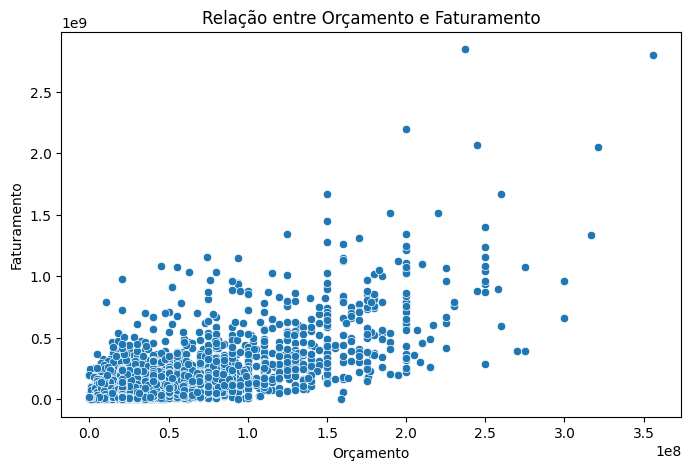

In [166]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.scatterplot(x='budget', y='gross', data=df)

plt.title('Relação entre Orçamento e Faturamento')
plt.xlabel('Orçamento')
plt.ylabel('Faturamento')

plt.show()

**CONCLUSÃO**

Observa-se uma relação positiva entre orçamento e faturamento, indicando que filmes com maior investimento tendem a gerar maior retorno financeiro. No entanto, a dispersão dos dados demonstra que essa relação não é perfeita, havendo filmes com alto orçamento que não alcançam grande faturamento e vice-versa.

##Hipótese 2: Existem gêneros mais lucrativos que outros?

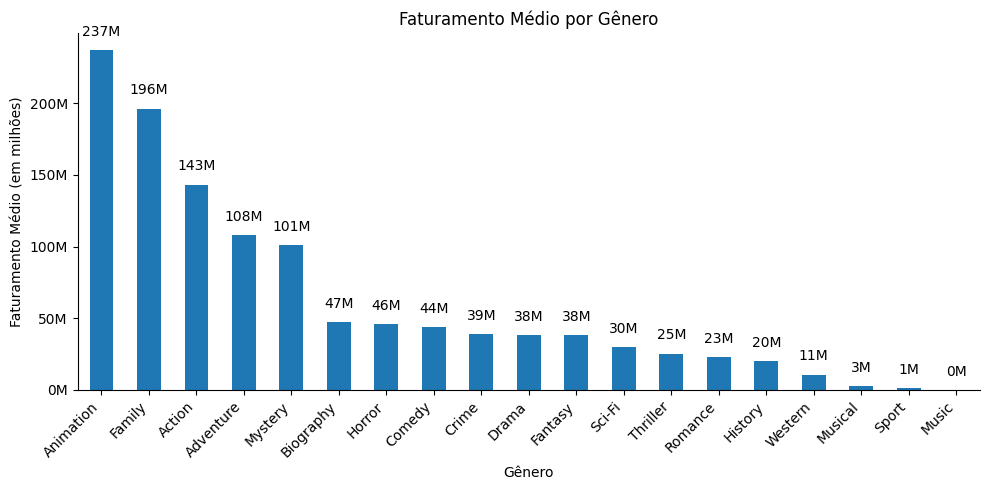

In [167]:
import seaborn as sns
import matplotlib.pyplot as plt

df_genre = df.groupby('genre')['gross'].mean().sort_values(ascending=False)

ax = df_genre.plot(kind='bar', figsize=(10,5))

plt.title('Faturamento Médio por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Faturamento Médio (em milhões)')

plt.xticks(rotation=45, ha='right')

# eixo em milhões
plt.gca().yaxis.set_major_formatter(lambda x, _: f'{x/1e6:.0f}M')

# tirar o "quadrado"
sns.despine()

# valores nas barras
for i, v in enumerate(df_genre):
    ax.text(i, v + 1e7, f'{v/1e6:.0f}M', ha='center')

plt.tight_layout()
plt.show()

**CONCLUSÃO**

A análise indica que determinados gêneros (como "animação", "família" e "ação") apresentam maior faturamento médio, sugerindo que há preferência do público por certos tipos de conteúdo. No entanto, a quantidade de filmes por gênero pode influenciar esses resultados, devendo ser considerada na interpretação.

##Hipótese 3: Filmes de certas empresas performam melhor?

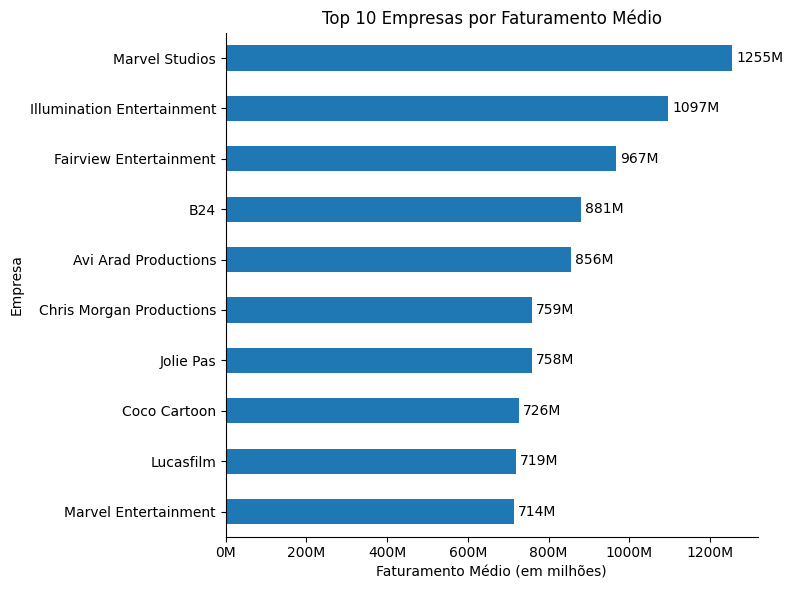

In [168]:
import seaborn as sns
import matplotlib.pyplot as plt

df_company = df.groupby('company')['gross'].mean().sort_values(ascending=True).tail(10)

ax = df_company.plot(kind='barh', figsize=(8,6))

plt.title('Top 10 Empresas por Faturamento Médio')
plt.xlabel('Faturamento Médio (em milhões)')
plt.ylabel('Empresa')

# formatar eixo X em milhões
plt.gca().xaxis.set_major_formatter(lambda x, _: f'{x/1e6:.0f}M')

# remover "caixa" do gráfico
sns.despine()

# adicionar valores nas barras
for i, v in enumerate(df_company):
    ax.text(v + 1e7, i, f'{v/1e6:.0f}M', va='center')

plt.tight_layout()
plt.show()

**CONCLUSÃO**

A análise do faturamento médio por empresa evidencia que determinadas produtoras apresentam desempenho financeiro significativamente superior às demais. Observa-se que empresas consolidadas no mercado cinematográfico concentram os maiores valores médios de faturamento, indicando uma possível vantagem competitiva.

Esse resultado pode estar associado a fatores como maior capacidade de investimento, estratégias de marketing mais robustas, distribuição global e participação em grandes franquias de sucesso.

Além disso, é importante considerar que o faturamento médio pode ser influenciado pela quantidade de filmes produzidos por cada empresa, bem como pela presença de outliers (filmes com desempenho excepcionalmente alto).

Dessa forma, os resultados sugerem que a produtora exerce influência no desempenho financeiro dos filmes, corroborando parcialmente a hipótese proposta.

#Conclusão do Projeto

O presente estudo teve como objetivo analisar fatores que influenciam o desempenho financeiro de filmes, utilizando um conjunto de dados contendo informações entre 1980 e 2020. A partir da análise exploratória dos dados, foi possível identificar padrões relevantes e responder às hipóteses propostas.

Em relação ao orçamento, observou-se uma relação positiva com o faturamento, indicando que filmes com maior investimento tendem a gerar maior retorno financeiro. No entanto, a presença de grande dispersão nos dados demonstra que o orçamento não é o único fator determinante para o sucesso.

Quanto aos gêneros cinematográficos, verificou-se que alguns apresentam faturamento médio superior, sugerindo preferência do público por determinados tipos de conteúdo. Ainda assim, a quantidade de filmes por gênero e a presença de sucessos isolados podem influenciar esses resultados.

No que diz respeito às empresas produtoras, identificou-se que determinadas organizações apresentam melhor desempenho financeiro médio, o que pode estar relacionado à sua estrutura, capacidade de investimento e atuação em grandes produções.

Além disso, a análise evidenciou uma distribuição altamente assimétrica do faturamento, caracterizada por poucos filmes com receitas extremamente elevadas e muitos com desempenho moderado ou baixo. Esse comportamento reforça a ideia de que o sucesso na indústria cinematográfica é concentrado em um número reduzido de produções.

Dessa forma, conclui-se que o desempenho financeiro dos filmes é influenciado por múltiplos fatores, incluindo orçamento, gênero e produtora, mas também por elementos não capturados diretamente no dataset, como estratégia de marketing, contexto de lançamento e aceitação do público.